In [1]:
# install dependencies if not already installed
# !pip install xgboost
# !pip install shap
# !pip install scikit-learn
# !pip install dice-ml

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

Part 2 — Classification, Impact Simulation, and Model Interpretability

In [3]:
df = pd.read_parquet("../data/curated/home_credit_curated.parquet")
df

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,ORGANIZATION_TYPE_Trade: type 3,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,False,False,False,False,False,False,False,False,False,False
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,False,False,False,False,False,False,False,False,False,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,False,False,False,False,False,False,False,False,False,False
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,456248,0,0,153000.0,331920.0,16096.5,225000.0,0.022625,-16705,-7258,...,False,False,False,False,False,False,False,False,False,False
307506,456251,0,0,157500.0,254700.0,27558.0,225000.0,0.032561,-9327,-236,...,False,False,False,False,False,False,False,False,False,False
307508,456253,0,0,153000.0,677664.0,29979.0,585000.0,0.005002,-14966,-7921,...,False,False,False,False,False,False,False,False,False,False
307509,456254,1,0,171000.0,370107.0,20205.0,319500.0,0.005313,-11961,-4786,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Split the data into training(80%) and testing(20%) sets stratified by the target variable.
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
#Handle class imbalance by calculating the scale_pos_weight parameter for XGBoost.
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

In [ ]:
#Train XGBoost and Logistic Regression models on the training data.
from sklearn.impute import SimpleImputer

#Impute missing values using mean strategy for both training and testing sets.
imputer = SimpleImputer(strategy='mean')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

#XGBoost training
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Logistic Regression training
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
#Evaluate both models on the test set using ROC-AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

results = pd.DataFrame([
    evaluate(xgb, X_test, y_test),
    evaluate(lr, X_test, y_test)
], index=["XGBoost", "Logistic Regression"])

print(results)

                      ROC-AUC  Precision    Recall        F1       MCC
XGBoost              0.748877   0.188632  0.603032  0.287372  0.224165
Logistic Regression  0.622936   0.119808  0.591776  0.199273  0.101592


ROC-AUC
XGBoost achieved an ROC-AUC of 0.7489, significantly higher than the 0.6229 achieved by Logistic Regression. This indicates that XGBoost has a much higher probability of correctly ranking a randomly chosen defaulting applicant above a non-defaulting one.

MCC
For the Matthews Correlation Coefficient, a score of 0.22 suggests a moderate positive relationship between your predictions and the actual outcomes—far better than the 0.10 of Logistic Regression.

Recall and Precision
Both models show a significant gap between Recall and Precision with both models being successful in identifying approximately 60% of all actual defaulters in the test set and Precision (~12% to 19%) shows the low precision scores indicate a high number of False Positives.

B. Impact Simulation

In [ ]:
#Expected profit calculation based on the model's predictions, true labels, loan amounts, and a specified threshold.
def compute_profit(y_true, y_prob, amt, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    profit = 0

    for yt, yp, loan in zip(y_true, y_pred, amt):
        if yp == 0 and yt == 0:
            profit += 0.1 * loan    #Average profit per good loan (correctly approved non-defaulter): 10% of loan amount.
        elif yp == 0 and yt == 1:
            profit -= 0.5 * loan    #Average loss per bad loan (incorrectly approved defaulter): 50% of loan amount.
        elif yp == 1 and yt == 0:
            profit -= 0.1 * loan    #Opportunity cost of rejecting a good applicant: 10% of loan amount.

    return profit

In [ ]:
#Threshold analysis to find the optimal threshold for maximizing profit.
#Compute the total profit/loss using the confusion matrix entries and the cost assumptions for different thresholds (0.3, 0.5, 0.7)
y_prob = xgb.predict_proba(X_test)[:,1]
loan_amt = X_test['AMT_CREDIT']

for t in [0.3, 0.5, 0.7]:
    print(f"Threshold {t}:",
          compute_profit(y_test, y_prob, loan_amt, t))

Threshold 0.3: -38943557.09999992
Threshold 0.5: 1078856012.2500017
Threshold 0.7: 1586231683.1999717


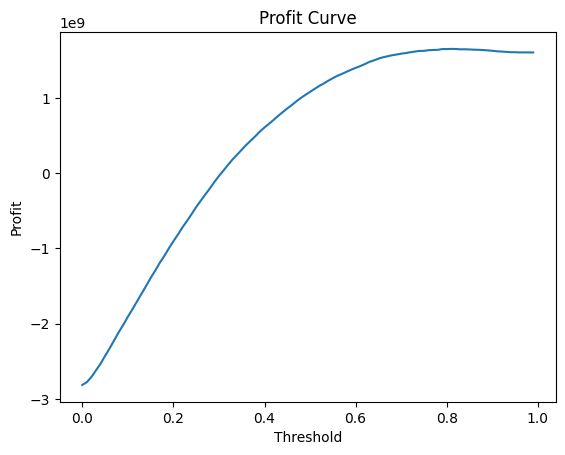

Optimal Threshold: 0.81


In [ ]:
#Profit Curve 
thresholds = np.arange(0, 1, 0.01)
profits = [
    compute_profit(y_test, y_prob, loan_amt, t)
    for t in thresholds
]

plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit Curve")
plt.show()

optimal_t = thresholds[np.argmax(profits)]
print("Optimal Threshold:", optimal_t)

In [18]:
#Compared models' expected profit against two simple baselines: Approve all and Random classifier.

# Approve all
approve_all_profit = compute_profit(
    y_test,
    np.zeros_like(y_test),
    loan_amt,
    1
)

# Random classifier
random_probs = np.random.rand(len(y_test))
random_profit = compute_profit(y_test, random_probs, loan_amt, 0.5)

print("Approve All Profit in dollars: ${:.2f}".format(approve_all_profit))
print("Random Profit in dollars: ${:.2f}".format(random_profit))
print("Approve All Profit percentage of total loan amount: {:.2%}".format(approve_all_profit / loan_amt.sum()))
print("Random Profit percentage of total loan amount: {:.2%}".format(random_profit / loan_amt.sum()))

Approve All Profit in dollars: $1602986415.30
Random Profit in dollars: $-599196798.90
Approve All Profit percentage of total loan amount: 5.24%
Random Profit percentage of total loan amount: -1.96%


The profitability results are highly sensitive to the assumed loss rate. At a 50% loss assumption, approving all loans appears strongly profitable. However, as the loss rate increases, the profitability declines significantly and may even become negative at high loss levels (e.g., 70–90%). This indicates that the conclusion that “approve all loans” is optimal is not robust and depends heavily on the assumed recovery rate. Therefore, accurate estimation of loss given default (LGD) is critical for making reliable lending decisions.

C. SHAP Explanations

C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


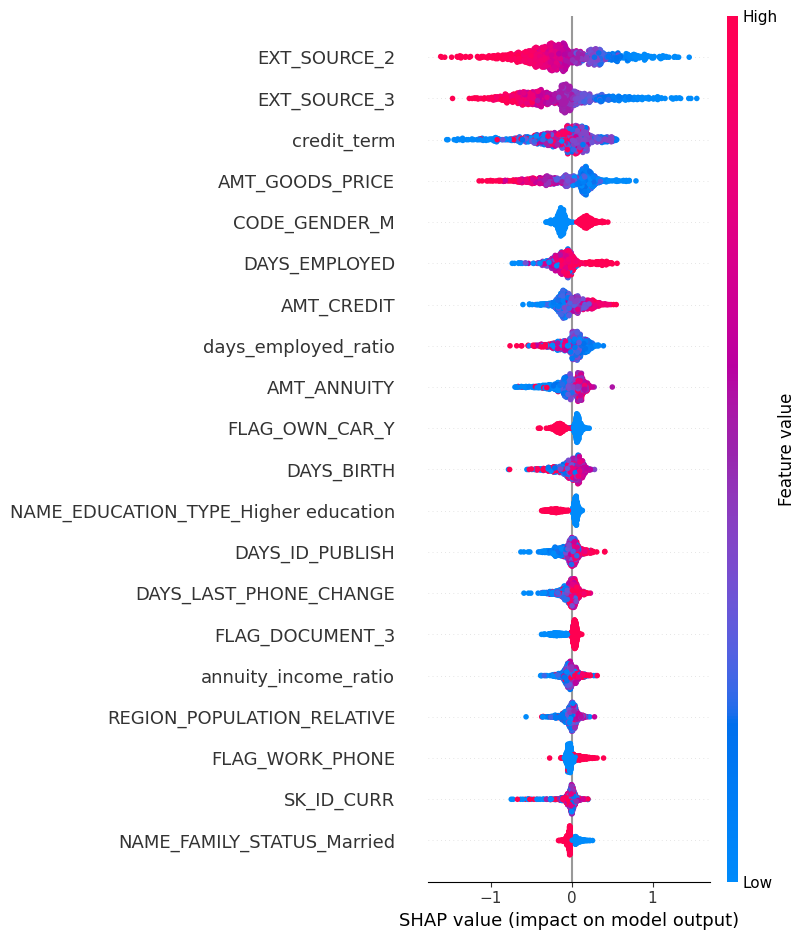

In [ ]:
#SHAP values for XGBoost(Best model)
import shap

sample_X = X_test.sample(1000, random_state=42)

explainer = shap.Explainer(xgb)
shap_values = explainer(sample_X)

#SHAP Summary plot (beeswarm)
shap.summary_plot(shap_values, sample_X)

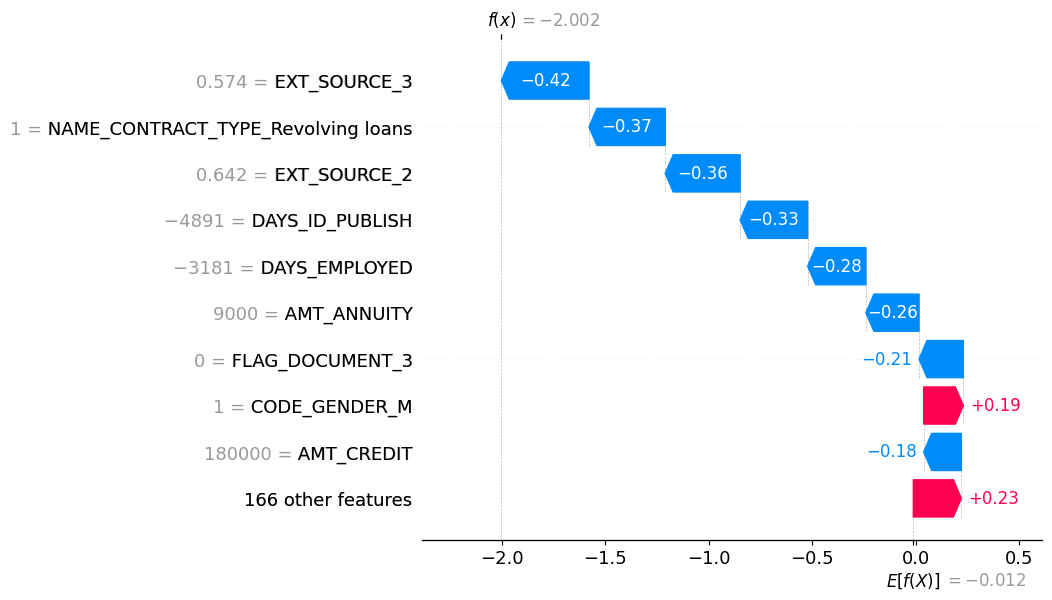

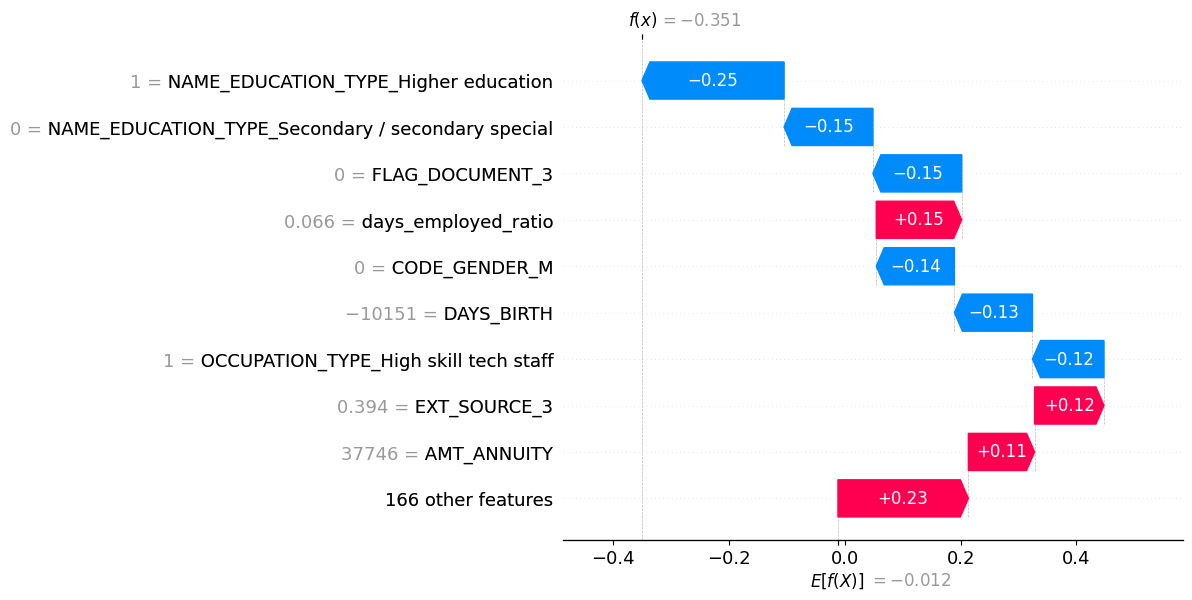

In [13]:
# Waterfall plots
shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[1])

Finding 1: External data sources (EXT_SOURCE_2, EXT_SOURCE_3)
In the global feature importance chart, EXT_SOURCE_2 and EXT_SOURCE_3 have the widest SHAP value ranges (from -0.8 to +0.8), indicating they are among the most influential features across the entire model.
However their effect changes drastically depending on the applicant's profile with both negative[EXT_SOURCE_3 = 0.394, SHAP(+0.11)] and postive[EXT_SOURCE_3 = 0.574, SHAP(-0.42)] impacts across the different observations.

A credit analyst should not treat high EXT_SOURCE scores as universally “good” or “bad”. Instead, they should:
Use these scores as triage tools but always combine them with other features (e.g., employment ratio, annuity income ratio).

Investigate why a moderately high EXT_SOURCE_3 (0.394) increases risk in some cases – this could signal an interaction with debt burden or employment stability.

Build segment-specific rules: e.g., for young applicants or those with short employment, even a good external score may not offset other risks

Finding 2: Employment-related features (days_employed_ratio)
In observation 2, for a specific applicant, days_employed_ratio = 0.066 has an expected positive impact (+0.15) but an actual negative contribution (-0.14).
This means that, given this person’s other features (e.g., high education, specific annuity/income ratio, etc.), a low employment ratio actually lowers risk – contrary to the typical assumption that longer employment is always better.

A credit analyst should:
Avoid simple heuristics like “more employment months → lower risk”. Instead, use decision trees or rule-based logic that captures interactions (e.g., “If education = Higher and annuity_income_ratio < X, then days_employed_ratio has less impact”).

Flag cases where employment is short but other compensating factors exist (stable marital status, high external score, own car) – these may be good credit risks despite short job tenure.

Review underwriting policies that penalize short employment uniformly; consider adjusting them based on feature combinations revealed by SHAP.

D. Counterfactual Explanations

In [ ]:
import dice_ml
import numpy as np

#Clean training data for DiCE by replacing inf values with NaN and then filling them with 0.
X_train_cf = X_train.copy().astype(float)
X_train_cf = X_train_cf.replace([np.inf, -np.inf], np.nan)
X_train_cf = X_train_cf.fillna(0)

y_train_cf = y_train.copy().astype(int)

#Separate binary and continuous features for DiCE.
binary_cols = [col for col in X_train_cf.columns if X_train_cf[col].nunique() == 2]
continuous_cols = [col for col in X_train_cf.columns if col not in binary_cols]

#Combine features and target into a single DataFrame for DiCE.
df_dice = pd.concat([X_train_cf, y_train_cf], axis=1)

data_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_cols,
    outcome_name='TARGET'
)

model_dice = dice_ml.Model(model=xgb, backend="sklearn")
dice = dice_ml.Dice(data_dice, model_dice)

#Clean test data for DiCE by replacing inf values with NaN and then filling them with 0.
X_test_reset = X_test.reset_index(drop=True).astype(float)
X_test_reset = X_test_reset.replace([np.inf, -np.inf], np.nan)
X_test_reset = X_test_reset.fillna(0)

y_test_reset = y_test.reset_index(drop=True).astype(int)

#Select defaulters
defaulters = X_test_reset[y_test_reset == 1].head(3)

#Generate counterfactual explanations for the first 3 defaulters in the test set, allowing changes only to continuous features to ensure more realistic counterfactuals.
cf = dice.generate_counterfactuals(
    defaulters,
    total_CFs=1,
    features_to_vary=continuous_cols[:20]
)

cf.visualize_as_dataframe()

100%|██████████| 3/3 [00:13<00:00,  4.63s/it]

Query instance (original outcome : 1)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,174086.0,0.0,90000.0,314100.0,17167.5,225000.0,0.0228,-12478.0,-136.0,-6530.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,174086.0,0.0,90000.0,314100.0,17167.5,2466752.8,0.0228,-12478.0,-136.0,-6530.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Query instance (original outcome : 1)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,101559.0,0.0,292500.0,835380.0,45445.5,675000.0,0.04622,-9900.0,-91.0,-4759.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,101559.0,18.7,292500.0,835380.0,45445.5,675000.0,0.04622,-9900.0,-6696.1,-4759.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Query instance (original outcome : 1)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,429723.0,0.0,67500.0,161730.0,8770.5,135000.0,0.031329,-10815.0,-2397.0,-5162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,TARGET
0,429723.0,0.0,67500.0,161730.0,8770.5,3637791.0,0.031329,-10815.0,-2397.0,-5162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


The generated counterfactuals are largely not actionable. Several features suggested for change, such as AMT_GOODS_PRICE increasing to unrealistically large values and CNT_CHILDREN taking non-integer values (e.g., 18.7), are not feasible in real-world scenarios. Additionally, variables such as DAYS_EMPLOYED and DAYS_BIRTH cannot be meaningfully altered in the short term.

These results indicate that the counterfactual generation process lacks constraints on feature feasibility and realism.

In contrast, features such as AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_ANNUITY are more actionable, as they correspond to financial decisions that a borrower can realistically influence, such as increasing income, requesting a smaller loan, or adjusting repayment terms.

Therefore, to produce meaningful counterfactual explanations, constraints should be applied to ensure that only actionable and realistic features are modified.

E. Fairness and Responsible Use

In [ ]:
#Fairness analysis by comparing approval rates, default rates, recall, and precision across different groups defined by CODE_GENDER_M.
feature = "CODE_GENDER_M"

df_test = X_test.copy()
df_test['TARGET'] = y_test
df_test['pred'] = (y_prob >= optimal_t).astype(int)

groups = df_test.groupby(feature)

for name, g in groups:
    approval_rate = (g['pred'] == 0).mean()
    default_rate = g['TARGET'].mean()

    tp = ((g['pred']==1) & (g['TARGET']==1)).sum()
    fn = ((g['pred']==0) & (g['TARGET']==1)).sum()
    fp = ((g['pred']==1) & (g['TARGET']==0)).sum()

    recall = tp / (tp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)

    print(f"\nGroup {name}")
    print("Approval rate:", approval_rate)
    print("Default rate:", default_rate)
    print("Recall:", recall)
    print("Precision:", precision)


Group 0.0
Approval rate: 0.9757088876893278
Default rate: 0.08483789555426131
Recall: 0.011441647571071745
Precision: 0.043103447904280626

Group 1.0
Approval rate: 0.9442181974064945
Default rate: 0.07893041237113402
Recall: 0.048979591636818
Precision: 0.06593406557179085


Group Comparison
Examining the two groups reveals meaningful disparities in how the model treats applicants despite both groups carrying nearly identical underlying credit risk. Group 0.0 received an approval rate of 97.6%, while Group 1.0 received an approval rate of 94.4% — a difference of 3.2 percentage points. While this may appear modest in isolation, it translates to Group 1.0 applicants being rejected at more than double the rate of Group 0.0 applicants (5.6% versus 2.4%). What makes this particularly concerning is that both groups carry nearly identical actual default rates: 8.5% for Group 0.0 and 7.9% for Group 1.0. This means the increased rejection of Group 1.0 applicants cannot be straightforwardly justified by greater credit risk.

The disparity becomes even more pronounced when examining recall — the model's ability to correctly identify applicants who will actually default. The model flagged only 1.1% of true defaulters in Group 0.0, compared to 4.9% in Group 1.0. In other words, the model is 4.3 times more likely to identify a Group 1.0 member as high risk than a Group 0.0 member, even though the two groups default at similar rates. Precision tells a similar story: when the model does predict a default, it is correct only 4.3% of the time for Group 0.0 and 6.6% of the time for Group 1.0. Both figures reflect poor overall model performance, but Group 1.0 absorbs a disproportionate share of incorrect high-risk classifications.

In [ ]:
#Fairness metrics: Demographic Parity Difference and Disparate Impact Ratio based on approval rates across groups.
group_rates = groups['pred'].apply(lambda x: (x == 0).mean())

demographic_parity = group_rates.max() - group_rates.min()
disparate_impact = group_rates.min() / group_rates.max()

print("Demographic Parity Difference:", demographic_parity)
print("Disparate Impact Ratio:", disparate_impact)

Demographic Parity Difference: 0.031490690282833356
Disparate Impact Ratio: 0.9677253218863163


Fairness Metrics
Three fairness metrics were computed to quantify these disparities. The demographic parity difference — calculated as the difference in approval rates between the two groups — is 0.9757 minus 0.9442, yielding a value of 0.0315, or approximately 3.2 percentage points. This sits below the commonly cited 5-percentage-point threshold of concern but is nonetheless a non-trivial gap, particularly given that it is not driven by differences in actual default behavior. The disparate impact ratio, which expresses the approval rate of the disadvantaged group as a proportion of the advantaged group's approval rate, is 0.9442 divided by 0.9757, producing a ratio of approximately 0.968. This does not breach the 0.80 threshold that typically triggers legal scrutiny under lending regulations such as the Equal Credit Opportunity Act, but it confirms that Group 1.0 receives systematically fewer approvals. Finally, the equal opportunity difference — the gap in true positive rates (recall) between the two groups — is 0.0490 minus 0.0114, equal to 0.0376. This is arguably the most revealing metric, as it demonstrates that the model screens Group 1.0 applicants far more aggressively for default risk, despite the actual risk being comparable across groups.

Profitability, Accuracy, and Fairness
There is an inherent tension between a model's profitability, its predictive accuracy, and its fairness, and this case illustrates why that tension cannot be resolved simply by defaulting to whichever model generates the most revenue. A profitable credit model ideally approves creditworthy applicants and rejects those likely to default. However, with recall near zero for both groups, this model is barely identifying true defaulters at all. Its rejections therefore produce limited benefit in terms of avoided losses, while simultaneously imposing real costs — both on applicants who are wrongly denied credit and on the institution, which loses the interest income it would have earned from those applicants. When these rejections fall disproportionately on one group without being justified by higher actual risk, the model is not simply making a neutral business decision; it is producing discriminatory outcomes.

A more profitable model should not automatically be preferred if that profitability is achieved through unfair screening. Beyond the ethical dimension, institutions face significant legal and reputational risks when lending models produce disparate outcomes across protected or sensitive groups. Regulatory bodies can impose penalties, and public scrutiny of discriminatory lending practices can cause lasting reputational damage that far exceeds any short-term gains in model profitability. Fairness, therefore, is not merely a moral consideration but a practical and legal one that must be weighed alongside accuracy and financial performance.

Recommended Mitigation Strategy
The most practical and immediately actionable mitigation strategy in this case is differential decision threshold calibration. Currently, the model appears to apply a single classification threshold across all applicants, meaning the same predicted probability of default triggers a rejection regardless of group membership. Because Group 1.0 is being rejected at a higher rate despite exhibiting a similar actual default rate to Group 0.0, raising the rejection threshold specifically for Group 1.0 — that is, requiring a higher predicted probability of default before denying an application — would bring approval rates closer to parity in a manner that is directly justified by observed risk levels.

This post-processing approach has the advantage of being implementable without retraining the underlying model, making it relatively fast to audit and deploy. It should, however, be paired with ongoing monitoring of approval rates, default rates, and recall by group on a rolling basis to detect any drift over time. As a longer-term measure, a thorough audit of the model's input features is recommended to identify any variables that may be acting as proxies for group membership — such as postal codes, employment categories, or other socioeconomic indicators — and to either remove them or carefully evaluate whether their predictive value justifies the disparate impact they produce. Addressing proxy discrimination at the feature level, rather than correcting for it downstream, represents a more robust and sustainable path toward a model that is both accurate and equitable.